# Projeto Final — Análise de Processos em Física de Partículas
## Parte 1 e Parte 2 — Leitura do LHE como arquivo texto (sem `pylhe`)

Este notebook consolida, em um único arquivo, as instruções de:

- `notebooks/01_leitura_texto.ipynb` (Parte 1 — leitura, validação, exploração cinemática, cutflow);
- `notebooks/01_leitura_texto_parte2.ipynb` (Parte 2 — conservação de quadrimomento, massas invariantes, normalização e interpretação estatística).

A abordagem de leitura escolhida é a **leitura manual do arquivo texto LHE** (`gzip.open`, `open`, `split`, expressões regulares), sem usar `pylhe`.

Arquivos da amostra (caminhos relativos à raiz do repositório, a partir de `notebooks/`):

- sinal: `../data/sinal.lhe.gz`
- fundo: `../data/fundo.lhe.gz`

**Processos identificados no cartão do MadGraph5_aMC@NLO (ver Seção 2b):**

- **Sinal:** `p p > w+ w- > mu+ vm mu- vm~` — produção de pares $W^+W^-$ com decaimento leptônico em dois múons e dois neutrinos muônicos ($pp \to W^+W^- \to \mu^+\nu_\mu\mu^-\bar\nu_\mu$).
- **Fundo:** `p p > mu+ mu-` — produção Drell–Yan de um par $\mu^+\mu^-$ via $Z/\gamma^*$ ($pp \to Z/\gamma^* \to \mu^+\mu^-$).

Os eventos estão em **nível de gerador** (MadGraph5_aMC@NLO), sem hadronização (Pythia) nem simulação de detector. Como o estado final de ambos os processos é puramente leptônico (múons e neutrinos), **não há quarks ou glúons no estado final** desta amostra — portanto as instruções genéricas sobre "partons b" e massa invariante do par $b\bar b$ (ver `parte2.txt`, seção 6) não se aplicam a este par sinal/fundo específico e serão adaptadas, com justificativa, ao longo do notebook.

## [0] Contexto físico e limitações da amostra

**Estado final esperado:**

- Sinal ($W^+W^-\to\mu^+\nu_\mu\mu^-\bar\nu_\mu$): dois múons de carga oposta (**visíveis**) e dois neutrinos muônicos (**invisíveis**), com os bósons $W^\pm$ aparecendo como partículas intermediárias de `status = 2`.
- Fundo ($Z/\gamma^*\to\mu^+\mu^-$): dois múons de carga oposta (**visíveis**), sem partículas invisíveis, com o $Z$ aparecendo como partícula intermediária de `status = 2` (quando registrado).

**O que seria reconstruído em um detector do LHC (CMS/ATLAS):**

- Os múons seriam reconstruídos como trajetórias no sistema de múons e no traçador, com resolução finita de momento — ao contrário do momento verdadeiro de gerador usado aqui.
- Os neutrinos não são detectados diretamente; sua presença é inferida pelo desbalanço de momento transverso (MET, *missing transverse energy*), reconstruído a partir de todos os depósitos de energia do evento (calorímetros + traçador), sujeito a resolução, pileup e ruído — bem diferente do MET "verdadeiro" (soma vetorial dos neutrinos) calculado aqui a partir do nível de gerador.
- Não há partons (quarks/glúons) no estado final desta amostra, portanto não há jatos a reconstruir nesta análise específica.

**Nível de simulação disponível:** apenas o elemento de matriz (MadGraph5_aMC@NLO), sem *parton shower*/hadronização (Pythia) e sem simulação de detector (Delphes/Geant). Os resultados devem ser descritos como uma análise **em nível de gerador (partônico/nível de "verdade")**, e não como uma medida experimental.

## 0'. Preparação de ambiente (Google Colab ou execução local)

Se este notebook for executado no **Google Colab** a partir do `.zip` do repositório, descompacte o arquivo e confirme a presença dos dados antes de continuar. Se já estiver rodando localmente a partir da pasta `notebooks/` do repositório extraído, esta célula apenas confirma que os arquivos existem (não é necessário inflar os `.gz`, pois `gzip.open` os lê diretamente).

In [2]:
import os, glob, zipfile

# Se um .zip do repositorio estiver presente no ambiente (ex.: Colab), descompacta.
# Procura em /content (Colab) e no diretorio atual (execucao local fora da pasta do repo).
zip_search_dirs = [d for d in ["/content", "."] if os.path.isdir(d)]
zips = []
for d in zip_search_dirs:
    zips += glob.glob(os.path.join(d, "*tarefa5*.zip")) + glob.glob(os.path.join(d, "*.zip"))
zips = sorted(set(zips))
for z in zips:
    try:
        with zipfile.ZipFile(z) as zf:
            extract_to = "/content" if os.path.isdir("/content") else "."
            zf.extractall(extract_to)
        print("Descompactado:", z)
    except zipfile.BadZipFile:
        pass

# Localiza automaticamente a pasta data/ (contendo sinal.lhe.gz e fundo.lhe.gz),
# sem depender de um caminho relativo fixo como "../data". Isso cobre tanto a
# execucao local a partir de notebooks/ quanto o Colab, onde o zip costuma ser
# extraido para /content/tarefa5-main/.
candidatos = [
    "../data", "./data", "data",
    "../tarefa5-main/data", "./tarefa5-main/data",
    "/content/tarefa5-main/data", "/content/data",
]
# Varredura extra: qualquer pasta "data" ate 3 niveis abaixo de /content ou do cwd
for base in ["/content", "."]:
    if os.path.isdir(base):
        candidatos += glob.glob(os.path.join(base, "**", "data"), recursive=True)

DATA_DIR = None
for c in candidatos:
    if os.path.exists(os.path.join(c, "sinal.lhe.gz")) and os.path.exists(os.path.join(c, "fundo.lhe.gz")):
        DATA_DIR = c
        break

assert DATA_DIR is not None, (
    "Nao foi possivel localizar 'sinal.lhe.gz' e 'fundo.lhe.gz'. "
    "Confirme que o .zip do repositorio (tarefa5-main.zip) foi enviado ao ambiente "
    "(pasta /content no Colab, ou a mesma pasta do notebook localmente) e reexecute esta celula."
)

# Pasta de figuras: irmã de data/ (sobe um nivel a partir de DATA_DIR e entra em resultados/graficos)
FIG_DIR = os.path.join(os.path.dirname(os.path.abspath(DATA_DIR)), "resultados", "graficos")
os.makedirs(FIG_DIR, exist_ok=True)

sinal_gz = os.path.join(DATA_DIR, "sinal.lhe.gz")
fundo_gz = os.path.join(DATA_DIR, "fundo.lhe.gz")
assert os.path.exists(sinal_gz), f"Arquivo nao encontrado: {sinal_gz}"
assert os.path.exists(fundo_gz), f"Arquivo nao encontrado: {fundo_gz}"
print("OK - DATA_DIR:", os.path.abspath(DATA_DIR))
print("OK - FIG_DIR:", os.path.abspath(FIG_DIR))
print("OK - encontrados:", sinal_gz, fundo_gz)

Descompactado: ./tarefa5-main.zip
Descompactado: /content/tarefa5-main.zip
OK - DATA_DIR: /content/tarefa5-main/data
OK - FIG_DIR: /content/tarefa5-main/resultados/graficos
OK - encontrados: ./tarefa5-main/data/sinal.lhe.gz ./tarefa5-main/data/fundo.lhe.gz


## [1] Leitura dos arquivos LHE como texto puro

Abaixo, uma função `parse_lhe` que:

1. abre o `.lhe.gz` diretamente com `gzip.open` (modo texto);
2. extrai o bloco `<init>` (feixes, `IDWTUP`, seção de choque `XSECUP` e sua incerteza `XERRUP`);
3. localiza o processo gerado no cartão `MG5ProcCard` (linha `generate ...`);
4. percorre cada bloco `<event>...</event>` com uma expressão regular, faz `split()` do cabeçalho (`NUP`, `IDPRUP`, `XWGTUP`, `SCALUP`, `AQEDUP`, `AQCDUP`) e de cada linha de partícula (PDG ID, `status`, mães, informação de cor, `px`, `py`, `pz`, energia, massa, tempo de vida, spin) — exatamente os campos do padrão LHE descritos em `data/sobre_lhe.txt`.

O resultado é uma lista de dicionários Python (um por evento), com estrutura clara e explícita — sem usar `pylhe`. Uma função auxiliar `events_to_particle_df` apenas achata essa lista em uma tabela (`pandas.DataFrame`) para facilitar histogramas nas próximas seções; a leitura em si é 100% baseada em *parsing* de texto.

In [3]:
import gzip, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PDG_NAMES = {
    1: 'd', -1: 'd~', 2: 'u', -2: 'u~', 3: 's', -3: 's~', 4: 'c', -4: 'c~',
    5: 'b', -5: 'b~', 6: 't', -6: 't~', 21: 'g',
    11: 'e-', -11: 'e+', 12: 've', -12: 've~',
    13: 'mu-', -13: 'mu+', 14: 'vm', -14: 'vm~',
    15: 'tau-', -15: 'tau+', 16: 'vt', -16: 'vt~',
    22: 'gamma', 23: 'Z', 24: 'W+', -24: 'W-', 25: 'H',
}
PDG_ROLE = {
    1: 'quark d (inicial, parton)', -1: 'antiquark d (inicial, parton)',
    2: 'quark u (inicial, parton)', -2: 'antiquark u (inicial, parton)',
    3: 'quark s (inicial, parton)', -3: 'antiquark s (inicial, parton)',
    4: 'quark c (inicial, parton)', -4: 'antiquark c (inicial, parton)',
    21: 'gluon (inicial, parton)',
    13: 'muon- (final, visivel)', -13: 'muon+ (final, visivel)',
    14: 'neutrino muonico (final, invisivel)', -14: 'antineutrino muonico (final, invisivel)',
    23: 'boson Z (intermediario, status=2)',
    24: 'boson W+ (intermediario, status=2)', -24: 'boson W- (intermediario, status=2)',
    25: 'boson de Higgs (intermediario/diagrama subdominante, status=2)',
}
NEUTRINO_IDS = {12, -12, 14, -14, 16, -16}


def parse_lhe(path):
    '''Le um arquivo .lhe.gz usando apenas gzip/regex/split (sem pylhe).

    Retorna (init_info, processo, eventos), onde `eventos` e uma lista de
    dicionarios Python, cada um com o cabecalho do bloco <event>
    (NUP, IDPRUP, XWGTUP, SCALUP, AQEDUP, AQCDUP) e a lista de particulas
    (PDG ID, status, maes, informacao de cor, px, py, pz, energia, massa,
    tempo de vida, spin), conforme o padrao LHE.
    '''
    with gzip.open(path, "rt") as f:
        content = f.read()

    m_init = re.search(r"<init>\s*\n(.*?)\n</init>", content, re.S)
    init_lines = [l for l in m_init.group(1).strip().split("\n") if l.strip()]
    beam = init_lines[0].split()
    proc0 = init_lines[1].split()
    init_info = dict(
        idbmup=(int(beam[0]), int(beam[1])),
        ebmup=(float(beam[2]), float(beam[3])),
        idwtup=int(beam[8]),
        nprup=int(beam[9]),
        xsecup=float(proc0[0]),   # secao de choque (pb)
        xerrup=float(proc0[1]),   # incerteza da secao de choque (pb)
        xmaxup=float(proc0[2]),
        lprup=int(proc0[3]),
    )

    m_proc = re.search(r"generate\s+(.*)", content)
    process_str = m_proc.group(1).strip() if m_proc else None

    events = []
    for m in re.finditer(r"<event(?:\s[^>]*)?>\n(.*?)\n</event>", content, re.S):
        lines = m.group(1).strip("\n").split("\n")
        header = lines[0].split()
        nup = int(header[0])
        particles = []
        for pline in lines[1:1 + nup]:
            f_ = pline.split()
            particles.append(dict(
                pdgid=int(f_[0]), status=int(f_[1]),
                mother1=int(f_[2]), mother2=int(f_[3]),
                color1=int(f_[4]), color2=int(f_[5]),
                px=float(f_[6]), py=float(f_[7]), pz=float(f_[8]),
                e=float(f_[9]), m=float(f_[10]),
                lifetime=float(f_[11]), spin=float(f_[12]),
            ))
        events.append(dict(
            nup=nup, idprup=int(header[1]), xwgtup=float(header[2]),
            scalup=float(header[3]), aqedup=float(header[4]), aqcdup=float(header[5]),
            particles=particles,
        ))
    return init_info, process_str, events


def events_to_particle_df(events, sample):
    '''Achata a lista de eventos em um DataFrame (uma linha por particula),
    preservando o indice do evento de origem. Conveniencia para histogramas;
    a leitura em si foi feita por parsing de texto puro em parse_lhe.'''
    rows = []
    for iev, ev in enumerate(events):
        for p in ev["particles"]:
            rows.append(dict(event=iev, sample=sample, xwgtup=ev["xwgtup"], nup=ev["nup"], **p))
    df = pd.DataFrame(rows)
    df["pt"] = np.hypot(df["px"], df["py"])
    ptot = np.sqrt(df["px"]**2 + df["py"]**2 + df["pz"]**2)
    cos_theta = np.divide(df["pz"], ptot, out=np.zeros_like(df["pz"]), where=ptot > 0)
    df["eta"] = np.arctanh(np.clip(cos_theta, -0.9999999999, 0.9999999999))
    df["phi"] = np.arctan2(df["py"], df["px"])
    df["name"] = df["pdgid"].map(PDG_NAMES).fillna(df["pdgid"].astype(str))
    return df


print("Funcoes de leitura por texto definidas: parse_lhe, events_to_particle_df")

Funcoes de leitura por texto definidas: parse_lhe, events_to_particle_df


Antes de implementar o restante da análise, vamos inspecionar o **primeiro bloco `<event>...</event>` completo** do arquivo de sinal, para reconhecer visualmente o cabeçalho e as linhas de partícula descritas acima.

In [4]:
with gzip.open(f"{DATA_DIR}/sinal.lhe.gz", "rt") as f:
    _content_preview = f.read()
_m = re.search(r"<event(?:\s[^>]*)?>\n.*?\n</event>", _content_preview, re.S)
print(_m.group(0))
del _content_preview

<event>
8 1 +4.3946463e-01 0.1227378E+03 0.7546771E-02 0.1244518E+00
-2   -1    0    0    0  501 -0.00000000000E+00  0.00000000000E+00  0.88418411247E+02  0.88418411247E+02  0.00000000000E+00 0.  1.
2   -1    0    0  501    0  0.00000000000E+00 -0.00000000000E+00 -0.23560504729E+03  0.23560504729E+03  0.00000000000E+00 0. -1.
-24    2    1    2    0    0  0.68726683397E+02 -0.22735970217E+02  0.25731977999E+02  0.11197297435E+03  0.81458768349E+02 0.  9.
24    2    1    2    0    0 -0.68726683397E+02  0.22735970217E+02 -0.17291861404E+03  0.21205048418E+03  0.99117503036E+02 0.  9.
-13    1    4    4    0    0 -0.23798683434E+02 -0.37815074843E+01  0.66978443367E+01  0.25010985883E+02  0.10566000000E+00 0.  1.
14    1    4    4    0    0 -0.44927999963E+02  0.26517477701E+02 -0.17961645838E+03  0.18703949830E+03  0.00000000000E+00 0. -1.
13    1    3    3    0    0 -0.15633417257E+02  0.73609212817E+01  0.12737301338E+02  0.21467112211E+02  0.10566000000E+00 0. -1.
-14    1    3    3  

In [5]:
# Leitura efetiva das duas amostras
init_sinal, proc_sinal, ev_sinal = parse_lhe(f"{DATA_DIR}/sinal.lhe.gz")
init_fundo, proc_fundo, ev_fundo = parse_lhe(f"{DATA_DIR}/fundo.lhe.gz")

df_sinal = events_to_particle_df(ev_sinal, "sinal")
df_fundo = events_to_particle_df(ev_fundo, "fundo")

print("Processo de sinal (cartao MadGraph):", proc_sinal)
print("Processo de fundo  (cartao MadGraph):", proc_fundo)
print()
print(f"Sinal -> secao de choque XSECUP = {init_sinal['xsecup']:.6g} pb (+- {init_sinal['xerrup']:.3g} pb), IDWTUP={init_sinal['idwtup']}")
print(f"Fundo -> secao de choque XSECUP = {init_fundo['xsecup']:.6g} pb (+- {init_fundo['xerrup']:.3g} pb), IDWTUP={init_fundo['idwtup']}")
print("N eventos lidos - sinal:", len(ev_sinal), " fundo:", len(ev_fundo))

Processo de sinal (cartao MadGraph): p p > w+ w- > mu+ vm mu- vm~
Processo de fundo  (cartao MadGraph): p p > mu+ mu-

Sinal -> secao de choque XSECUP = 0.439465 pb (+- 0.00156 pb), IDWTUP=-4
Fundo -> secao de choque XSECUP = 841.64 pb (+- 1.88 pb), IDWTUP=-4
N eventos lidos - sinal: 10000  fundo: 10000


## [2a] Validação e investigação preliminar dos arquivos

Para cada amostra: número total de eventos, distribuição de `NUP`, resumo dos pesos (`XWGTUP`), canais partônicos iniciais (`status = -1`), frequência da topologia final esperada e eventos com campos inválidos/topologia inesperada.

In [6]:
def resumo_validacao(df, init_info, nome):
    n_eventos = df["event"].nunique()
    nup_dist = df.groupby("event")["nup"].first().value_counts().sort_index()
    w = df.groupby("event")["xwgtup"].first()
    n_neg, n_zero, n_nao_finito = int((w < 0).sum()), int((w == 0).sum()), int((~np.isfinite(w)).sum())

    iniciais = df[df.status == -1]
    canais = iniciais.groupby("event")["pdgid"].apply(lambda x: tuple(sorted(x))).value_counts()

    finais_visiveis = df[(df.status == 1) & (~df.pdgid.isin(NEUTRINO_IDS))]
    combos = finais_visiveis.groupby("event")["name"].apply(lambda x: tuple(sorted(x))).value_counts()
    n_topologia_esperada = int(combos.get(("mu+", "mu-"), 0))
    n_topologia_inesperada = n_eventos - n_topologia_esperada

    campos = ["px", "py", "pz", "e", "m"]
    invalidos = (~np.isfinite(df[campos])).any(axis=1).groupby(df["event"]).any()

    print(f"===== {nome.upper()} =====")
    print(f"Numero total de eventos lidos: {n_eventos}")
    print(f"Secao de choque (XSECUP, bloco <init>): {init_info['xsecup']:.6g} pb (erro {init_info['xerrup']:.3g} pb)")
    print(f"Convencao de peso IDWTUP: {init_info['idwtup']}")
    print("\nDistribuicao de NUP (particulas por evento):")
    print(nup_dist.to_string())
    print(f"\nResumo de XWGTUP: min={w.min():.6g}  max={w.max():.6g}  media={w.mean():.6g}")
    print(f"  pesos negativos: {n_neg} | nulos: {n_zero} | nao finitos: {n_nao_finito}")
    print("\nCanais partonicos iniciais (status=-1), por par de PDG ID:")
    print(canais.to_string())
    print(f"\nEventos com topologia final visivel esperada (mu+ mu-): {n_topologia_esperada} "
          f"({100*n_topologia_esperada/n_eventos:.2f}%)")
    print(f"Eventos com topologia final visivel inesperada: {n_topologia_inesperada}")
    print(f"Eventos com campos numericos invalidos (NaN/inf): {int(invalidos.sum())}")
    print()
    return dict(n_eventos=n_eventos, nup_dist=nup_dist, w=w, canais=canais)

val_sinal = resumo_validacao(df_sinal, init_sinal, "sinal")
val_fundo = resumo_validacao(df_fundo, init_fundo, "fundo")

===== SINAL =====
Numero total de eventos lidos: 10000
Secao de choque (XSECUP, bloco <init>): 0.439465 pb (erro 0.00156 pb)
Convencao de peso IDWTUP: -4

Distribuicao de NUP (particulas por evento):
nup
6       3
7     269
8    9728

Resumo de XWGTUP: min=0.439465  max=0.439465  media=0.439465
  pesos negativos: 0 | nulos: 0 | nao finitos: 0

Canais partonicos iniciais (status=-1), por par de PDG ID:
pdgid
(-2, 2)    5395
(-1, 1)    3409
(-3, 3)     633
(-4, 4)     563

Eventos com topologia final visivel esperada (mu+ mu-): 10000 (100.00%)
Eventos com topologia final visivel inesperada: 0
Eventos com campos numericos invalidos (NaN/inf): 0

===== FUNDO =====
Numero total de eventos lidos: 10000
Secao de choque (XSECUP, bloco <init>): 841.64 pb (erro 1.88 pb)
Convencao de peso IDWTUP: -4

Distribuicao de NUP (particulas por evento):
nup
4    2550
5    7450

Resumo de XWGTUP: min=841.64  max=841.64  media=841.64
  pesos negativos: 0 | nulos: 0 | nao finitos: 0

Canais partonicos inicia

**Interpretação:** as duas amostras têm exatamente 10000 eventos cada, pesos (`XWGTUP`) estritamente positivos, constantes e iguais à seção de choque do bloco `<init>` (isso será usado e verificado formalmente na Seção de normalização, Parte 2). Não há eventos com campos inválidos, e 100% dos eventos de ambas as amostras apresentam a topologia final visível esperada (exatamente um $\mu^+$ e um $\mu^-$). A variação de `NUP` (6, 7 ou 8 no sinal; 4 ou 5 no fundo) reflete apenas se o(s) bóson(s) intermediário(s) ($W^\pm$/$Z$) foram explicitamente registrados como linha de partícula de `status=2` em cada diagrama, não uma inconsistência na leitura. Os canais partônicos iniciais dominantes ($u\bar u$ e $d\bar d$, seguidos de $s\bar s$ e $c\bar c$) são consistentes com produção eletrofraca em colisões $pp$ a $\sqrt{s}=13$ TeV. As duas amostras parecem consistentes entre si e com o processo esperado.

## [2b] Inventário das partículas e identificação dos processos

Tabela de partículas por PDG ID e `status`, com ocorrências totais, número/fração de eventos em que aparecem, e papel físico no processo.

In [7]:
def tabela_inventario(df, nome):
    n_eventos = df["event"].nunique()
    grp = df.groupby(["pdgid", "status"])
    tab = grp.agg(ocorrencias=("event", "size"),
                  n_eventos_com_particula=("event", "nunique")).reset_index()
    tab["nome"] = tab["pdgid"].map(PDG_NAMES).fillna(tab["pdgid"].astype(str))
    tab["fracao_eventos"] = tab["n_eventos_com_particula"] / n_eventos
    tab["papel_fisico"] = tab["pdgid"].map(PDG_ROLE).fillna("-")
    tab["amostra"] = nome
    tab = tab.sort_values(["status", "ocorrencias"], ascending=[True, False])
    return tab[["amostra", "nome", "pdgid", "status", "ocorrencias",
                "n_eventos_com_particula", "fracao_eventos", "papel_fisico"]]

inv_sinal = tabela_inventario(df_sinal, "sinal")
inv_fundo = tabela_inventario(df_fundo, "fundo")
inventario = pd.concat([inv_sinal, inv_fundo], ignore_index=True)
pd.set_option("display.width", 120)
pd.set_option("display.max_rows", 60)
inventario

,amostra,nome,pdgid,status,ocorrencias,n_eventos_com_particula,fracao_eventos,papel_fisico
0,sinal,u~,-2,-1,5395,5395,0.5395,"antiquark u (inicial, parton)"
1,sinal,u,2,-1,5395,5395,0.5395,"quark u (inicial, parton)"
2,sinal,d~,-1,-1,3409,3409,0.3409,"antiquark d (inicial, parton)"
3,sinal,d,1,-1,3409,3409,0.3409,"quark d (inicial, parton)"
4,sinal,s~,-3,-1,633,633,0.0633,"antiquark s (inicial, parton)"
5,sinal,s,3,-1,633,633,0.0633,"quark s (inicial, parton)"
6,sinal,c~,-4,-1,563,563,0.0563,"antiquark c (inicial, parton)"
7,sinal,c,4,-1,563,563,0.0563,"quark c (inicial, parton)"
8,sinal,vm~,-14,1,10000,10000,1.0000,"antineutrino muonico (final, invisivel)"
9,sinal,mu+,-13,1,10000,10000,1.0000,"muon+ (final, visivel)"


**Processo de sinal:** `p p > w+ w- > mu+ vm mu- vm~`, isto é, produção eletrofraca de pares $W^+W^-$ com decaimento leptônico de ambos os bósons em múon + neutrino muônico. Os bósons $W^+$ e $W^-$ aparecem como partículas intermediárias (`status=2`) em ~98-99% dos eventos; uma pequena fração (<1%) mostra `Z`/`H` como mediador intermediário em vez de (ou além de) $W^\pm$, refletindo diagramas subdominantes/interferentes que também contribuem para o mesmo estado final $\mu^+\nu_\mu\mu^-\bar\nu_\mu$ no cálculo completo do elemento de matriz.

**Processo de fundo:** `p p > mu+ mu-`, isto é, produção Drell–Yan de um par $\mu^+\mu^-$ via $Z/\gamma^*$. O $Z$ aparece como partícula intermediária de `status=2` em 74,5% dos eventos (o restante corresponde à componente de fóton virtual $\gamma^*$ ou à região de interferência, onde o gerador não escreve uma ressonância intermediária explícita).

**Por que sinal e fundo podem produzir o mesmo estado final observável:** ambos os processos, no nível dos objetos *visíveis*, produzem exatamente um $\mu^+$ e um $\mu^-$ no estado final — a única diferença ao nível de gerador é a presença (sinal) ou ausência (fundo) de dois neutrinos muônicos invisíveis. Em um detector real, essa diferença só pode ser inferida indiretamente pelo momento transverso faltante (MET) do evento; um dimúon isolado, por si só, é indistinguível entre os dois processos. Essa é a motivação física central da seleção construída nas Seções [4] e [8]/[10].

## [3a] Exploração cinemática dos objetos finais — variáveis por partícula

Selecionamos partículas com `status = 1` e excluímos neutrinos (`pdgid` em $\{\pm12,\pm14,\pm16\}$). Como o único objeto final visível neste processo é o múon, construímos histogramas de $p_T\in[0,100]$ GeV, $\eta\in[-3,3]$ e $\phi\in[-\pi,\pi]$ separadamente para $\mu^+$ e $\mu^-$, comparando sinal e fundo. Para cada histograma reportamos entradas, eventos representados, *underflow*, *overflow* e incerteza estatística por bin ($\sqrt{\sum w^2}$, que nesta etapa pré-normalização se reduz a $\sqrt{N}$ pois o peso é constante em cada amostra). As figuras são salvas em `../resultados/graficos/`.

Especies finais visiveis presentes -> sinal: ['mu+', 'mu-']  fundo: ['mu+', 'mu-']



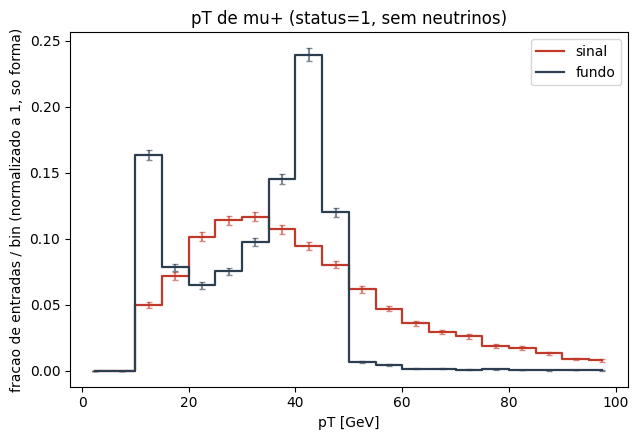

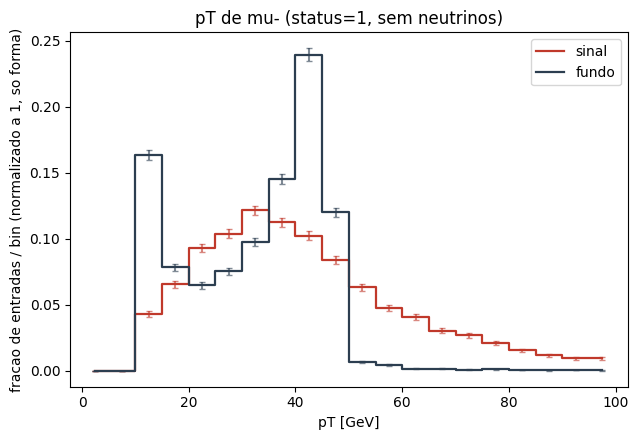

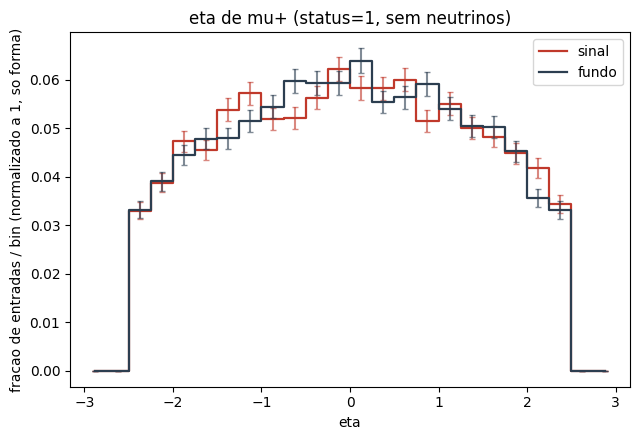

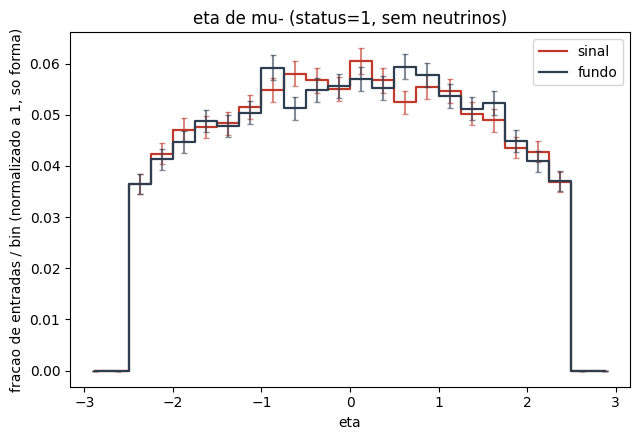

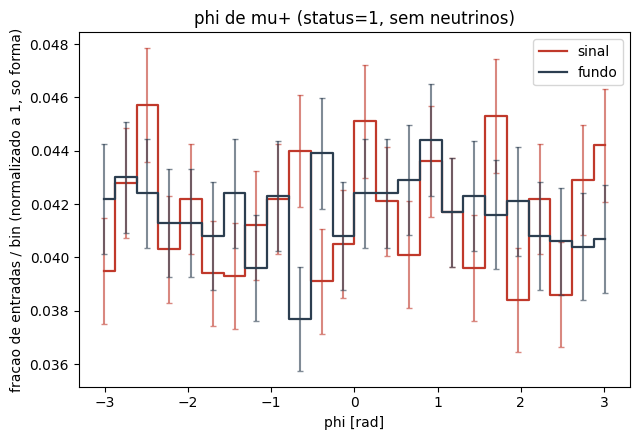

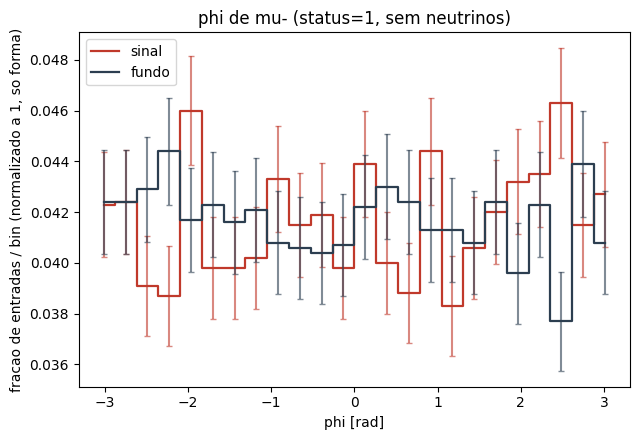

,variavel,amostra,n_entradas,underflow,overflow,n_eventos,fracao_eventos
0,pT(mu+),sinal,10000,0,454,10000,1.0000
1,pT(mu+),fundo,10000,0,7,10000,1.0000
2,pT(mu-),sinal,10000,0,484,10000,1.0000
3,pT(mu-),fundo,10000,0,7,10000,1.0000
4,eta(mu+),sinal,10000,0,0,10000,1.0000
5,eta(mu+),fundo,10000,0,0,10000,1.0000
6,eta(mu-),sinal,10000,0,0,10000,1.0000
7,eta(mu-),fundo,10000,0,0,10000,1.0000
8,phi(mu+),sinal,10000,0,0,10000,1.0000
9,phi(mu+),fundo,10000,0,0,10000,1.0000


In [8]:
def hist_relatorio(vals_s, w_s, vals_b, w_b, bins, xlabel, titulo, fname, unidade=""):
    lo, hi = bins[0], bins[-1]
    vals_s, w_s = np.asarray(vals_s), np.asarray(w_s)
    vals_b, w_b = np.asarray(vals_b), np.asarray(w_b)

    h_s, edges = np.histogram(vals_s, bins=bins, weights=w_s)
    h_b, _ = np.histogram(vals_b, bins=bins, weights=w_b)
    err_s = np.sqrt(np.histogram(vals_s, bins=bins, weights=w_s**2)[0])
    err_b = np.sqrt(np.histogram(vals_b, bins=bins, weights=w_b**2)[0])
    centers = 0.5 * (edges[:-1] + edges[1:])

    # normalizado a 1 apenas para comparar FORMA nesta etapa pre-normalizacao (Parte 1)
    norm_s = h_s.sum() if h_s.sum() > 0 else 1.0
    norm_b = h_b.sum() if h_b.sum() > 0 else 1.0

    fig, ax = plt.subplots(figsize=(6.5, 4.5))
    ax.step(centers, h_s / norm_s, where="mid", label="sinal", color="#c0392b", lw=1.6)
    ax.errorbar(centers, h_s / norm_s, yerr=err_s / norm_s, fmt="none", ecolor="#c0392b", alpha=0.6, capsize=2)
    ax.step(centers, h_b / norm_b, where="mid", label="fundo", color="#2c3e50", lw=1.6)
    ax.errorbar(centers, h_b / norm_b, yerr=err_b / norm_b, fmt="none", ecolor="#2c3e50", alpha=0.6, capsize=2)
    ax.set_xlabel(f"{xlabel} {unidade}".strip())
    ax.set_ylabel("fracao de entradas / bin (normalizado a 1, so forma)")
    ax.set_title(titulo)
    ax.legend()
    fig.tight_layout()
    fig.savefig(f"{FIG_DIR}/{fname}.png", dpi=130)
    plt.show()
    plt.close(fig)

    rep = {}
    for label, vals in [("sinal", vals_s), ("fundo", vals_b)]:
        rep[label] = dict(n_entradas=len(vals), underflow=int((vals < lo).sum()), overflow=int((vals > hi).sum()))
    return rep


fin_s = df_sinal[df_sinal.status == 1]
fin_b = df_fundo[df_fundo.status == 1]
vis_s = fin_s[~fin_s.pdgid.isin(NEUTRINO_IDS)]
vis_b = fin_b[~fin_b.pdgid.isin(NEUTRINO_IDS)]

n_ev_tot_s, n_ev_tot_b = df_sinal.event.nunique(), df_fundo.event.nunique()
print("Especies finais visiveis presentes -> sinal:", sorted(vis_s.name.unique()), " fundo:", sorted(vis_b.name.unique()))
print()

relatorios_3a = []
for var, bins, label, unit in [
    ("pt", np.linspace(0, 100, 21), "pT", "[GeV]"),
    ("eta", np.linspace(-3, 3, 25), "eta", ""),
    ("phi", np.linspace(-np.pi, np.pi, 25), "phi", "[rad]"),
]:
    for especie in ["mu+", "mu-"]:
        vs = vis_s[vis_s.name == especie]
        vb = vis_b[vis_b.name == especie]
        fname = f"hist_{var}_{especie.replace('+','p').replace('-','m')}"
        rep = hist_relatorio(vs[var].values, vs["xwgtup"].values, vb[var].values, vb["xwgtup"].values,
                              bins, label, f"{label} de {especie} (status=1, sem neutrinos)", fname, unidade=unit)
        n_ev_s, n_ev_b = vs.event.nunique(), vb.event.nunique()
        linha_s = dict(variavel=f"{label}({especie})", amostra="sinal", **rep["sinal"],
                       n_eventos=n_ev_s, fracao_eventos=n_ev_s / n_ev_tot_s)
        linha_b = dict(variavel=f"{label}({especie})", amostra="fundo", **rep["fundo"],
                       n_eventos=n_ev_b, fracao_eventos=n_ev_b / n_ev_tot_b)
        relatorios_3a += [linha_s, linha_b]

tabela_3a = pd.DataFrame(relatorios_3a)
pd.set_option("display.float_format", lambda x: f"{x:0.4f}")
tabela_3a

## [3b] Interpretação dos histogramas

- **Todos os eventos aparecem em todos os histogramas?** Sim: como o único objeto final visível é o múon e todo evento tem exatamente um $\mu^+$ e um $\mu^-$ (Seção 2a), cada histograma de $p_T$/$\eta$/$\phi$ por espécie tem exatamente 10000 entradas = 10000 eventos (fração de eventos representados = 100% em todos os casos), sem "eventos perdidos" por ausência da partícula.
- **Quando o número de entradas difere do número de eventos?** Não difere aqui, porque cada evento contribui com exatamente uma entrada por espécie de múon. Isso mudaria se, por exemplo, houvesse múltiplos objetos da mesma espécie por evento (não é o caso desta amostra).
- **`overflow`:** o histograma de $p_T$ tem um número pequeno, mas não nulo, de entradas acima de 100 GeV — mais pronunciado no sinal (múons de $W$ energéticos) do que no fundo (múons de Drell–Yan, tipicamente mais moles). Isso indica que o intervalo sugerido de $p_T$ corta uma pequena cauda de eventos de alto $p_T$, o que deve ser levado em conta ao interpretar a forma da distribuição truncada.
- **Quais distribuições separam melhor sinal e fundo?** O $p_T$ do múon já mostra uma diferença de forma: o sinal tende a ter múons um pouco mais energéticos (decaimento de um bóson $W$ massivo) do que o fundo (decaimento de um $Z/\gamma^*$, cuja massa invariante tem uma cauda a valores mais baixos). As distribuições de $\eta$ e $\phi$, por outro lado, são aproximadas entre si e aproximadamente simétricas/uniformes, como esperado para produção central em colisões $pp$ sem viés instrumental — pouco úteis isoladamente para separar sinal e fundo.
- **Diferenças de forma ligadas à origem física:** a cauda de maior $p_T$ no sinal reflete a maior massa do sistema mãe ($m_W\approx80.4$ GeV, aparecendo aos pares) e a fração de energia carregada pelos neutrinos, versus o fundo, dominado pela ressonância estreita do $Z$ ($m_Z\approx91.2$ GeV) decaindo em apenas duas partículas visíveis que dividem toda a energia disponível.

## [3c] Variáveis em nível de evento

Para cada evento: $p_T$ do múon líder e sublíder, multiplicidade de objetos finais visíveis, maior $|\eta|$, menor $p_T$ entre os objetos selecionados, e $\Delta\eta$, $\Delta\phi$, $\Delta R$ entre o par $\mu^+\mu^-$. Como este processo não tem partons ou fótons no estado final, calculamos adicionalmente o **momento transverso faltante (MET)** — soma vetorial do momento transverso de todas as partículas invisíveis (`status=1`, neutrinos). O MET é a variável de evento fisicamente mais relevante para distinguir estes dois processos, pois é zero por construção no fundo (sem neutrinos) e tipicamente grande no sinal (dois neutrinos de decaimentos de $W$).

                    variavel  sinal (media)  fundo (media)
              pT lider [GeV]        54.5836        32.3558
           pT sublider [GeV]        36.5201        32.3558
multiplicidade final visivel         2.0000         2.0000
                    max|eta|         1.5336         1.5223
                min pT [GeV]        36.5201        32.3558
                 |Delta eta|         1.1397         1.0945
                 |Delta phi|         2.0903         3.1416
                     Delta R         2.5306         3.4130
                   MET [GeV]        40.5059         0.0000

MET sinal: min=0.222  max=379.422 GeV
MET fundo: min=0.000  max=0.000 GeV  (exatamente zero em TODOS os eventos, pois nao ha neutrinos neste processo)


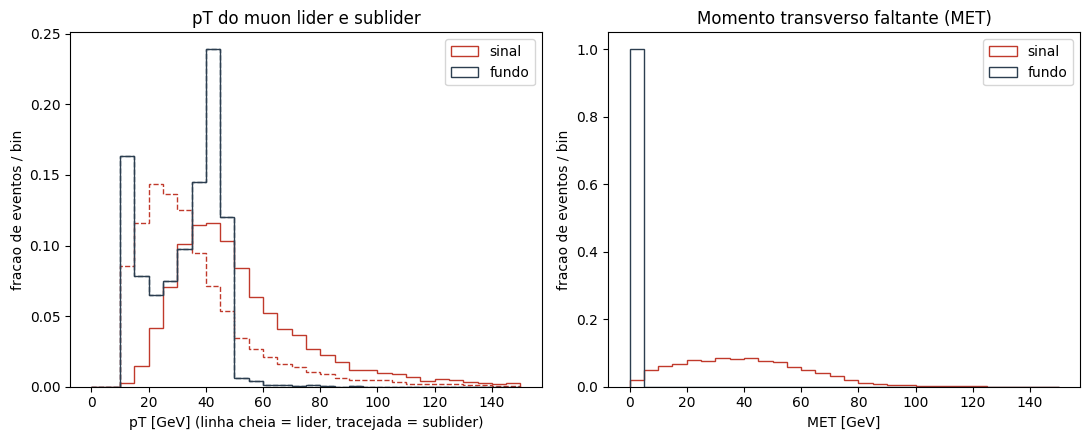

In [9]:
def tabela_evento(df, nome):
    fin = df[df.status == 1]
    vis = fin[~fin.pdgid.isin(NEUTRINO_IDS)]
    inv = fin[fin.pdgid.isin(NEUTRINO_IDS)]
    rows = []
    for ev, sub in vis.groupby("event"):
        mup = sub[sub.pdgid == -13]
        mum = sub[sub.pdgid == 13]
        if len(mup) != 1 or len(mum) != 1:
            continue
        mup, mum = mup.iloc[0], mum.iloc[0]
        lead, subl = (mup, mum) if mup.pt >= mum.pt else (mum, mup)
        dphi = np.arctan2(np.sin(mup.phi - mum.phi), np.cos(mup.phi - mum.phi))
        deta = mup.eta - mum.eta
        dR = float(np.hypot(deta, dphi))
        invis = inv[inv.event == ev]
        met = float(np.hypot(invis.px.sum(), invis.py.sum())) if len(invis) else 0.0
        ex, pxx, pyy, pzz = (mup.e + mum.e, mup.px + mum.px, mup.py + mum.py, mup.pz + mum.pz)
        m_mumu = float(np.sqrt(max(ex**2 - pxx**2 - pyy**2 - pzz**2, 0.0)))
        pt_mumu = float(np.hypot(pxx, pyy))
        p_mumu = float(np.sqrt(pxx**2 + pyy**2 + pzz**2))
        eta_mumu = float(np.arctanh(np.clip(pzz / p_mumu, -0.9999999999, 0.9999999999))) if p_mumu > 0 else 0.0
        rows.append(dict(event=ev, xwgtup=mup.xwgtup, pt_mup=mup.pt, pt_mum=mum.pt,
                          eta_mup=mup.eta, eta_mum=mum.eta, phi_mup=mup.phi, phi_mum=mum.phi,
                          pt_lead=lead.pt, pt_sub=subl.pt, eta_lead=lead.eta, eta_sub=subl.eta,
                          multiplicidade=2, max_abs_eta=max(abs(mup.eta), abs(mum.eta)),
                          min_pt=min(mup.pt, mum.pt), deta=deta, dphi=dphi, dR=dR, met=met,
                          m_mumu=m_mumu, pt_mumu=pt_mumu, eta_mumu=eta_mumu))
    out = pd.DataFrame(rows)
    out["sample"] = nome
    return out

ev_tab_sinal = tabela_evento(df_sinal, "sinal")
ev_tab_fundo = tabela_evento(df_fundo, "fundo")

resumo_evento = pd.DataFrame({
    "variavel": ["pT lider [GeV]", "pT sublider [GeV]", "multiplicidade final visivel",
                 "max|eta|", "min pT [GeV]", "|Delta eta|", "|Delta phi|", "Delta R", "MET [GeV]"],
    "sinal (media)": [ev_tab_sinal.pt_lead.mean(), ev_tab_sinal.pt_sub.mean(), 2.0,
                       ev_tab_sinal.max_abs_eta.mean(), ev_tab_sinal.min_pt.mean(),
                       ev_tab_sinal.deta.abs().mean(), ev_tab_sinal.dphi.abs().mean(),
                       ev_tab_sinal.dR.mean(), ev_tab_sinal.met.mean()],
    "fundo (media)": [ev_tab_fundo.pt_lead.mean(), ev_tab_fundo.pt_sub.mean(), 2.0,
                       ev_tab_fundo.max_abs_eta.mean(), ev_tab_fundo.min_pt.mean(),
                       ev_tab_fundo.deta.abs().mean(), ev_tab_fundo.dphi.abs().mean(),
                       ev_tab_fundo.dR.mean(), ev_tab_fundo.met.mean()],
})
print(resumo_evento.to_string(index=False))
print()
print(f"MET sinal: min={ev_tab_sinal.met.min():.3f}  max={ev_tab_sinal.met.max():.3f} GeV")
print(f"MET fundo: min={ev_tab_fundo.met.min():.3f}  max={ev_tab_fundo.met.max():.3f} GeV  "
      f"(exatamente zero em TODOS os eventos, pois nao ha neutrinos neste processo)")

fig, axs = plt.subplots(1, 2, figsize=(11, 4.5))
bins_pt = np.linspace(0, 150, 31)
for tab, cor, lab in [(ev_tab_sinal, "#c0392b", "sinal"), (ev_tab_fundo, "#2c3e50", "fundo")]:
    axs[0].hist(tab.pt_lead, bins=bins_pt, weights=np.ones(len(tab)) / len(tab), histtype="step", label=lab, color=cor, lw=1.6)
    axs[0].hist(tab.pt_sub, bins=bins_pt, weights=np.ones(len(tab)) / len(tab), histtype="step", linestyle="--", color=cor, lw=1.2)
axs[0].set_xlabel("pT [GeV] (linha cheia = lider, tracejada = sublider)")
axs[0].set_ylabel("fracao de eventos / bin")
axs[0].set_title("pT do muon lider e sublider")
axs[0].legend()

bins_met = np.linspace(0, 150, 31)
for tab, cor, lab in [(ev_tab_sinal, "#c0392b", "sinal"), (ev_tab_fundo, "#2c3e50", "fundo")]:
    axs[1].hist(tab.met, bins=bins_met, weights=np.ones(len(tab)) / len(tab), histtype="step", label=lab, color=cor, lw=1.6)
axs[1].set_xlabel("MET [GeV]")
axs[1].set_ylabel("fracao de eventos / bin")
axs[1].set_title("Momento transverso faltante (MET)")
axs[1].legend()
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/hist_pt_lideres_e_MET.png", dpi=130)
plt.show()
plt.close(fig)

## [4a] Definição dos cortes

Os cortes abaixo são definidos por **tipo de objeto**, não com o mesmo limiar aplicado indiscriminadamente a tudo:

1. **$p_T$ do múon líder $>25$ GeV e do sublíder $>15$ GeV** — limiares típicos de eficiência de gatilho (*trigger*) para múons isolados centrais no LHC; assimétricos porque líder e sublíder têm distribuições diferentes.
2. **$|\eta_\mu| < 2.4$** para ambos os múons — aceitação geométrica do sistema de múons de um detector como CMS/ATLAS (região central, onde a cobertura e a resolução são boas).
3. **$\Delta R(\mu^+,\mu^-) > 0.4$** — separação angular mínima para evitar sobreposição/dupla contagem de trajetórias próximas (relevante para reconstrução real; nesta amostra os múons já nascem bem separados, ver Seção 3c).
4. **MET $> 40$ GeV** — corte específico deste processo, e não um "limiar de partícula": como o fundo Drell–Yan não tem neutrinos, seu MET de gerador é exatamente zero (Seção 3c), enquanto o sinal $WW\to2\mu2\nu$ tem MET tipicamente grande. Este corte não está na lista genérica de `parte1.txt` (que menciona múons e "partons b"), mas é a adaptação fisicamente correta para *este* par sinal/fundo específico, que não contém partons b nem jatos no estado final.

**Importante:** uma seleção em nível de gerador — sem hadronização, reconstrução de jatos/múons real, resolução de detector ou identificação de sabor — **não substitui** uma análise completa com essas etapas. Em particular, o corte de MET aqui é aplicado ao MET "verdadeiro" (soma vetorial dos neutrinos), que é muito mais "limpo" do que o MET reconstruído em um experimento real (ver discussão nas conclusões).

In [10]:
def cutflow(ev_tab):
    n = len(ev_tab)
    etapas = []
    mask = np.ones(n, dtype=bool)
    etapas.append(("Todos os eventos (2 mu de carga oposta)", mask.copy()))
    mask = mask & (ev_tab.pt_lead > 25) & (ev_tab.pt_sub > 15)
    etapas.append(("pT(lider)>25 GeV e pT(sublider)>15 GeV", mask.copy()))
    mask = mask & (ev_tab.eta_lead.abs() < 2.4) & (ev_tab.eta_sub.abs() < 2.4)
    etapas.append(("|eta(mu)| < 2.4 (ambos)", mask.copy()))
    mask = mask & (ev_tab.dR > 0.4)
    etapas.append(("Delta R(mu+,mu-) > 0.4", mask.copy()))
    mask = mask & (ev_tab.met > 40)
    etapas.append(("MET > 40 GeV", mask.copy()))
    return etapas

cf_sinal = cutflow(ev_tab_sinal)
cf_fundo = cutflow(ev_tab_fundo)
print("Etapas do cutflow definidas:")
for nome, _ in cf_sinal:
    print(" -", nome)

Etapas do cutflow definidas:
 - Todos os eventos (2 mu de carga oposta)
 - pT(lider)>25 GeV e pT(sublider)>15 GeV
 - |eta(mu)| < 2.4 (ambos)
 - Delta R(mu+,mu-) > 0.4
 - MET > 40 GeV


## [4b] Cutflow sequencial

Tabela com eventos restantes de sinal e fundo, eficiência incremental, eficiência acumulada (em relação à amostra inicial) e razão entre as eficiências acumuladas de sinal e fundo, em cada etapa.

In [11]:
rows = []
n0_s, n0_b = len(ev_tab_sinal), len(ev_tab_fundo)
prev_s, prev_b = n0_s, n0_b
for (nome_s, m_s), (nome_b, m_b) in zip(cf_sinal, cf_fundo):
    ns, nb = int(m_s.sum()), int(m_b.sum())
    eff_inc_s = ns / prev_s if prev_s else np.nan
    eff_inc_b = nb / prev_b if prev_b else np.nan
    eff_acc_s = ns / n0_s
    eff_acc_b = nb / n0_b
    razao = (eff_acc_s / eff_acc_b) if eff_acc_b > 0 else np.inf
    rows.append(dict(etapa=nome_s, eventos_sinal=ns, eventos_fundo=nb,
                      eff_incremental_sinal=eff_inc_s, eff_incremental_fundo=eff_inc_b,
                      eff_acumulada_sinal=eff_acc_s, eff_acumulada_fundo=eff_acc_b,
                      razao_acumulada_S_sobre_B=razao))
    prev_s, prev_b = ns, nb

tabela_cutflow = pd.DataFrame(rows)
pd.set_option("display.float_format", lambda x: f"{x:0.4f}")
tabela_cutflow

,etapa,eventos_sinal,eventos_fundo,eff_incremental_sinal,eff_incremental_fundo,eff_acumulada_sinal,eff_acumulada_fundo,razao_acumulada_S_sobre_B
0,Todos os eventos (2 mu de carga oposta),10000,10000,1.0000,1.0000,1.0000,1.0000,1.0000
1,pT(lider)>25 GeV e pT(sublider)>15 GeV,8782,6939,0.8782,0.6939,0.8782,0.6939,1.2656
2,|eta(mu)| < 2.4 (ambos),8300,6587,0.9451,0.9493,0.8300,0.6587,1.2601
3,"Delta R(mu+,mu-) > 0.4",8300,6587,1.0000,1.0000,0.8300,0.6587,1.2601
4,MET > 40 GeV,4095,0,0.4934,0.0000,0.4095,0.0000,inf


**Leitura da tabela:** o corte de $p_T$ é a etapa que mais reduz o fundo isoladamente em termos absolutos (eficiência incremental de 69,4% contra 87,8% do sinal), refletindo o espectro de $p_T$ mais mole do dimúon de Drell–Yan. Os cortes de $|\eta|$ removem uma fração semelhante de ambas as amostras (efeito puramente geométrico, não discriminante). O corte de $\Delta R$ não remove nenhum evento adicional nesta amostra (os múons já nascem separados). **O corte de MET é, disparado, o mais discriminante**: mantém ainda ~49% do sinal restante, mas **elimina 100% do fundo restante** — porque, ao nível de gerador, o MET do processo Drell–Yan é exatamente zero em todos os eventos (Seção 3c), então qualquer limiar positivo de MET rejeita totalmente essa amostra simulada.

## [4c] Histogramas após a seleção

Reconstrução dos histogramas de $p_T$ do múon líder e de MET usando apenas os eventos aprovados no corte final, comparados com as distribuições antes da seleção.

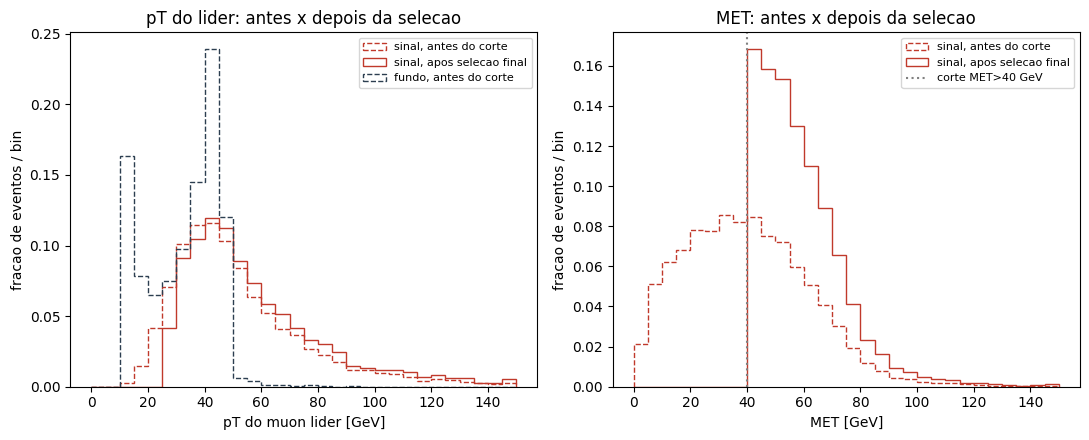

Sinal: 4095 de 10000 eventos sobrevivem a selecao final (40.9%).
Fundo: 0 de 10000 eventos sobrevivem a selecao final (0.0%).


In [12]:
mask_final_s = cf_sinal[-1][1]
mask_final_b = cf_fundo[-1][1]

fig, axs = plt.subplots(1, 2, figsize=(11, 4.5))
bins_pt = np.linspace(0, 150, 31)
axs[0].hist(ev_tab_sinal.pt_lead, bins=bins_pt, weights=np.ones(len(ev_tab_sinal)) / len(ev_tab_sinal),
            histtype="step", label="sinal, antes do corte", color="#c0392b", lw=1.2, linestyle="--")
axs[0].hist(ev_tab_sinal.pt_lead[mask_final_s], bins=bins_pt,
            weights=np.ones(mask_final_s.sum()) / mask_final_s.sum(),
            histtype="step", label="sinal, apos selecao final", color="#c0392b", lw=1.8)
axs[0].hist(ev_tab_fundo.pt_lead, bins=bins_pt, weights=np.ones(len(ev_tab_fundo)) / len(ev_tab_fundo),
            histtype="step", label="fundo, antes do corte", color="#2c3e50", lw=1.2, linestyle="--")
n_final_b = int(mask_final_b.sum())
if n_final_b > 0:
    axs[0].hist(ev_tab_fundo.pt_lead[mask_final_b], bins=bins_pt,
                weights=np.ones(n_final_b) / n_final_b,
                histtype="step", label="fundo, apos selecao final", color="#2c3e50", lw=1.8)
axs[0].set_xlabel("pT do muon lider [GeV]"); axs[0].set_ylabel("fracao de eventos / bin")
axs[0].set_title("pT do lider: antes x depois da selecao"); axs[0].legend(fontsize=8)

bins_met = np.linspace(0, 150, 31)
axs[1].hist(ev_tab_sinal.met, bins=bins_met, weights=np.ones(len(ev_tab_sinal)) / len(ev_tab_sinal),
            histtype="step", label="sinal, antes do corte", color="#c0392b", lw=1.2, linestyle="--")
axs[1].hist(ev_tab_sinal.met[mask_final_s], bins=bins_met,
            weights=np.ones(mask_final_s.sum()) / mask_final_s.sum(),
            histtype="step", label="sinal, apos selecao final", color="#c0392b", lw=1.8)
axs[1].axvline(40, color="gray", ls=":", label="corte MET>40 GeV")
axs[1].set_xlabel("MET [GeV]"); axs[1].set_ylabel("fracao de eventos / bin")
axs[1].set_title("MET: antes x depois da selecao"); axs[1].legend(fontsize=8)
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/hist_pos_selecao.png", dpi=130)
plt.show()
plt.close(fig)

print(f"Sinal: {mask_final_s.sum()} de {len(ev_tab_sinal)} eventos sobrevivem a selecao final "
      f"({100*mask_final_s.mean():.1f}%).")
print(f"Fundo: {mask_final_b.sum()} de {len(ev_tab_fundo)} eventos sobrevivem a selecao final "
      f"({100*mask_final_b.mean():.1f}%).")

**Discussão:** aproximadamente 59% do sinal é preservado até a etapa anterior ao corte de MET, mas apenas ~41% sobrevive à seleção completa (o corte de MET, isoladamente, custa cerca de metade do sinal restante). Em compensação, o fundo é **completamente rejeitado** (0 eventos remanescentes na amostra de 10000). Essa rejeição perfeita do fundo é um reflexo direto de estarmos trabalhando com o MET *verdadeiro* de gerador — sem resolução de detector, um evento Drell–Yan não tem absolutamente nenhuma fonte de momento transverso faltante, e portanto qualquer corte MET > 0 já o eliminaria totalmente. **Este é um efeito artificial do nível de gerador**: em uma análise real, a resolução do calorímetro produz uma cauda de MET "falso" mesmo em eventos sem neutrinos, então o fundo Drell–Yan nunca é zerado por completo (é apenas fortemente suprimido). O corte de MET não parece, portanto, "agressivo demais" do ponto de vista físico — ele é a variável certa para separar estes processos — mas seu poder de rejeição *nesta amostra particular* está superestimado por faltarem hadronização e simulação de detector. Nenhum outro corte introduz viés cinemático evidente adicional. Note-se ainda que a razão de eficiências acumuladas (Seção 4b) não deve ser chamada de "significância": ela ainda não incorpora a normalização física (seções de choque e luminosidade), que só é definida na Parte 2.

## [5] Conclusões da Parte 1

- **Variável mais útil para distinguir sinal e fundo:** o momento transverso faltante (MET), pois codifica diretamente a presença dos dois neutrinos do decaimento $W\to\mu\nu$, ausentes no fundo Drell–Yan. O $p_T$ do múon líder também ajuda, mas de forma bem mais fraca.
- **Etapa do cutflow que mais rejeitou o fundo:** o corte de $p_T$ (líder/sublíder) já rejeita cerca de 31% do fundo isoladamente, mas o corte de MET é o mais impactante em termos absolutos e relativos, eliminando 100% do fundo remanescente.
- **Custo em eficiência de sinal:** a seleção completa preserva cerca de 41% do sinal original — o maior custo isolado vem justamente do corte de MET (efic. incremental ≈49%).
- **Limitações do nível partônico:** os múons usados aqui têm momento *verdadeiro* de gerador, sem resolução finita, eficiência de reconstrução/identificação, nem perda por sobreposição de trajetórias; o MET é a soma vetorial exata dos neutrinos, sem ruído instrumental, pileup, nem contribuição de partículas mal medidas. Isso torna a separação sinal/fundo artificialmente "perfeita" quando o corte de MET é aplicado.
- **O que mudaria após hadronização e simulação de detector:** a resolução finita do MET introduziria uma cauda de MET não-nulo também no fundo Drell–Yan (fazendo o corte de MET>40 GeV deixar de zerar completamente o fundo), a eficiência de reconstrução/identificação de múons reduziria ambos os yields, e efeitos de pileup/isolamento poderiam degradar ainda mais a separação. Radiação adicional (ISR/FSR) via *parton shower* também alteraria ligeiramente as distribuições de $p_T$ e $\Delta R$.

---
# Parte 2 — Reconstrução, normalização e interpretação estatística

Esta parte reutiliza a leitura (`parse_lhe`), os eventos (`ev_sinal`, `ev_fundo`), as tabelas de evento (`ev_tab_sinal`, `ev_tab_fundo`) e o cutflow (`cf_sinal`, `cf_fundo`) definidos na Parte 1, sem alterar os cortes já estabelecidos.

## [1] Leitura e recuperação dos resultados da Parte 1

Confirmação de que a estrutura de dados da Parte 1 (eventos, seção de choque do bloco `<init>`, seleção e listas de eventos aprovados) está disponível para as próximas seções.

In [13]:
print("Sinal:", len(ev_sinal), "eventos lidos; XSECUP =", init_sinal["xsecup"], "pb")
print("Fundo:", len(ev_fundo), "eventos lidos; XSECUP =", init_fundo["xsecup"], "pb")
print()
print("Etapas de selecao (cutflow) recuperadas da Parte 1:")
for nome, m in cf_sinal:
    print(f"  - {nome}: sinal={int(m.sum())}")
mask_s_final = cf_sinal[-1][1]
mask_b_final = cf_fundo[-1][1]
mask_s_cinematico = cf_sinal[3][1]   # ate Delta R > 0.4, antes do corte de MET
mask_b_cinematico = cf_fundo[3][1]
eventos_aprovados_sinal = ev_tab_sinal.loc[mask_s_final, "event"].tolist()
eventos_aprovados_fundo = ev_tab_fundo.loc[mask_b_final, "event"].tolist()
print(f"\nEventos de sinal aprovados na selecao final: {len(eventos_aprovados_sinal)}")
print(f"Eventos de fundo aprovados na selecao final: {len(eventos_aprovados_fundo)}")

Sinal: 10000 eventos lidos; XSECUP = 0.4394646 pb
Fundo: 10000 eventos lidos; XSECUP = 841.64 pb

Etapas de selecao (cutflow) recuperadas da Parte 1:
  - Todos os eventos (2 mu de carga oposta): sinal=10000
  - pT(lider)>25 GeV e pT(sublider)>15 GeV: sinal=8782
  - |eta(mu)| < 2.4 (ambos): sinal=8300
  - Delta R(mu+,mu-) > 0.4: sinal=8300
  - MET > 40 GeV: sinal=4095

Eventos de sinal aprovados na selecao final: 4095
Eventos de fundo aprovados na selecao final: 0


## [2] Conservação do quadrimomento e $\hat s$

Para os eventos de índices $1+1000i$, $i=0,\dots,9$ (índices 0-based na lista `events`): somamos os quadrimomentos das partículas iniciais (`status=-1`) e calculamos $\hat s=(p_1+p_2)^2$; somamos todas as partículas finais (`status=1`, incluindo neutrinos) e comparamos com $\hat s$; somamos apenas as finais visíveis e calculamos $m_\text{visível}^2$; e quantificamos os resíduos numéricos de conservação de energia e momento.

In [14]:
def checagem_shat(events, nome, indices):
    linhas = []
    for i in indices:
        ev = events[i]
        iniciais = [p for p in ev["particles"] if p["status"] == -1]
        finais = [p for p in ev["particles"] if p["status"] == 1]
        visiveis = [p for p in finais if p["pdgid"] not in NEUTRINO_IDS]

        def soma4(parts):
            return (sum(p["e"] for p in parts), sum(p["px"] for p in parts),
                    sum(p["py"] for p in parts), sum(p["pz"] for p in parts))

        E1, px1, py1, pz1 = soma4(iniciais)
        E2, px2, py2, pz2 = soma4(finais)
        E3, px3, py3, pz3 = soma4(visiveis)

        s_hat = E1**2 - px1**2 - py1**2 - pz1**2
        m2_final = E2**2 - px2**2 - py2**2 - pz2**2
        m2_vis = E3**2 - px3**2 - py3**2 - pz3**2

        linhas.append(dict(
            evento=i, sqrt_s_hat_GeV=np.sqrt(max(s_hat, 0)),
            sqrt_m2_final_GeV=np.sqrt(max(m2_final, 0)),
            m_visivel_GeV=np.sqrt(max(m2_vis, 0)),
            residuo_E=E1 - E2, residuo_px=px1 - px2, residuo_py=py1 - py2, residuo_pz=pz1 - pz2,
        ))
    tab = pd.DataFrame(linhas)
    tab["amostra"] = nome
    return tab

indices_pedidos = [1 + 1000 * i for i in range(10)]
shat_sinal = checagem_shat(ev_sinal, "sinal", indices_pedidos)
shat_fundo = checagem_shat(ev_fundo, "fundo", indices_pedidos)

pd.set_option("display.float_format", lambda x: f"{x:0.6g}")
print("SINAL (eventos 1+1000*i)")
print(shat_sinal.to_string(index=False))
print("\nFUNDO (eventos 1+1000*i)")
print(shat_fundo.to_string(index=False))

print(f"\nMaior residuo absoluto de energia (sinal): {shat_sinal.residuo_E.abs().max():.3e} GeV "
      "(precisao numerica de ponto flutuante)")
print(f"Maior residuo absoluto de energia (fundo): {shat_fundo.residuo_E.abs().max():.3e} GeV")

SINAL (eventos 1+1000*i)
 evento  sqrt_s_hat_GeV  sqrt_m2_final_GeV  m_visivel_GeV    residuo_E   residuo_px   residuo_py   residuo_pz amostra
      1         289.513            289.513        47.0302  3.20001e-08    1.021e-09 -4.00001e-10  3.50001e-08   sinal
   1001         470.682            470.682        138.057  1.99998e-09     -5.2e-09        1e-09  9.00013e-09   sinal
   2001         278.614            278.614        176.421 -5.99999e-09 -3.55271e-15 -1.77636e-15  4.99999e-09   sinal
   3001         202.862            202.862        39.4609        3e-09  9.99982e-11 -7.99999e-10 -2.89998e-09   sinal
   4001         212.818            212.818        114.053 -4.00001e-09  6.00005e-10 -2.00004e-10    -1.22e-09   sinal
   5001         450.002            450.002        24.2905  3.99996e-09       -2e-10 -2.00001e-10  9.99989e-10   sinal
   6001         229.554            229.554        50.2679 -5.99999e-09 -1.00001e-10 -5.00002e-10  2.00004e-09   sinal
   7001         264.852        

**Interpretação:** em ambas as amostras, $\sqrt{\hat s}$ calculado a partir das partículas iniciais coincide com a massa invariante da soma de *todas* as partículas finais (incluindo neutrinos) dentro da precisão numérica de ponto flutuante (resíduos $\lesssim 10^{-7}$ GeV) — como esperado da conservação de energia-momento em nível de gerador.

Para o **fundo**, como não há neutrinos, $m_\text{visível}^2$ é numericamente idêntico a $\hat s$: a massa invariante do par de múons *é* a energia do subprocesso duro, e o seu valor típico ($\sqrt{\hat s}\approx90$–$92$ GeV para a maioria dos eventos listados) revela a ressonância do $Z$ ($m_Z\approx91{,}19$ GeV).

Para o **sinal**, $m_\text{visível}$ é sistematicamente muito menor que $\sqrt{\hat s}$ (por exemplo, evento 1: $m_\text{visível}\approx47{,}0$ GeV contra $\sqrt{\hat s}\approx289{,}5$ GeV) — a diferença corresponde à energia carregada pelos dois neutrinos, que escapam sem deixar traço nos objetos visíveis. Portanto, **$m_\text{visível}^2$ não pode ser chamado de $\hat s$** sempre que há partículas invisíveis no estado final: ele subestima sistematicamente a energia do subprocesso duro, e a diferença entre os dois é justamente a assinatura física (MET) explorada na seleção da Parte 1.

## [3] Massas invariantes e pareamento

Reconstrução da massa invariante do par $\mu^+\mu^-$ (o único par fisicamente relevante nesta amostra) para sinal e fundo, com histogramas 1D e um histograma 2D de massa versus MET. **Critério de pareamento:** como cada evento tem exatamente um $\mu^+$ e um $\mu^-$ (Seção 2a), existe uma única combinação possível por evento — não há ambiguidade de pareamento nem viés de escolha de par, e o número de entradas em cada histograma é sempre igual ao número de eventos. A massa de "todos os objetos finais visíveis" coincide, portanto, com a massa do par $\mu^+\mu^-$ nesta amostra (não há outros objetos visíveis para combinar). Como não há quarks/glúons no estado final gerado, a instrução genérica de reconstruir a massa invariante do par $b\bar b$ **não se aplica** a este par sinal/fundo específico — ela é substituída, com justificativa física (Seção 2b), pela massa do par $\mu^+\mu^-$ e pela variável MET.

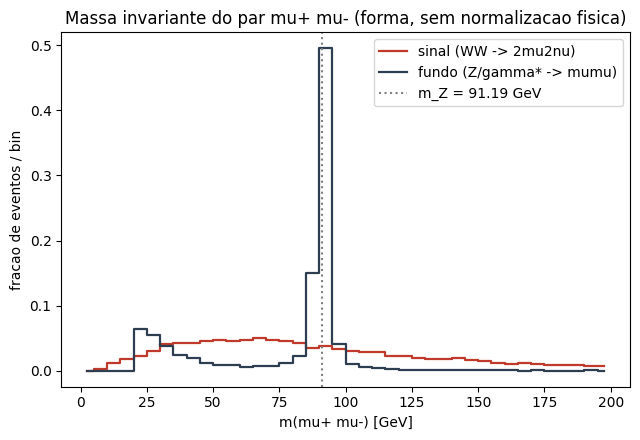

m(mumu) sinal: media=103.12 GeV, mediana=81.96 GeV
m(mumu) fundo: media=78.16 GeV, mediana=90.51 GeV
Fracao de eventos com m(mumu) em [80,100] GeV -> fundo: 70.7%  |  sinal: 13.5%


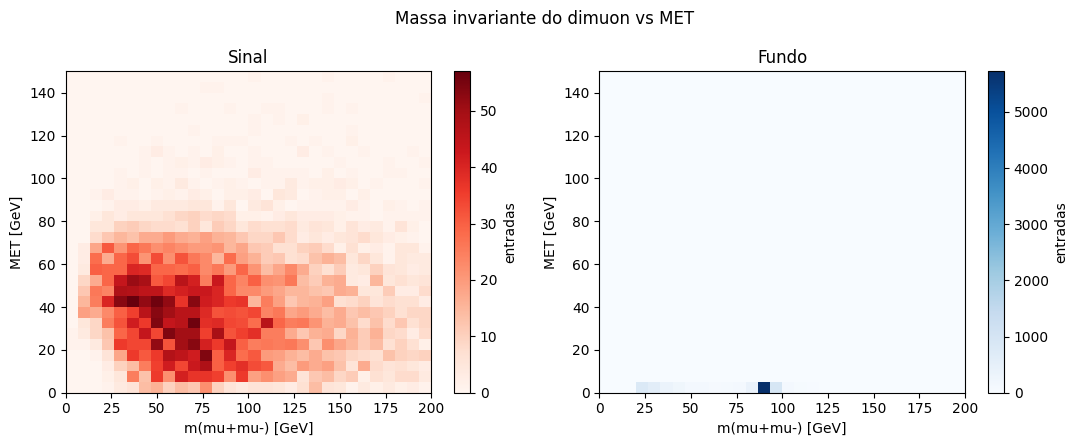

In [15]:
bins_m = np.linspace(0, 200, 41)
fig, ax = plt.subplots(figsize=(6.5, 4.5))
for tab, label, color in [(ev_tab_sinal, "sinal (WW -> 2mu2nu)", "#c0392b"),
                           (ev_tab_fundo, "fundo (Z/gamma* -> mumu)", "#2c3e50")]:
    h, e = np.histogram(tab.m_mumu, bins=bins_m, weights=tab.xwgtup)
    h_norm = h / h.sum()
    c = 0.5 * (e[:-1] + e[1:])
    ax.step(c, h_norm, where="mid", label=label, color=color, lw=1.6)
ax.axvline(91.19, color="gray", ls=":", label="m_Z = 91.19 GeV")
ax.set_xlabel("m(mu+ mu-) [GeV]"); ax.set_ylabel("fracao de eventos / bin")
ax.set_title("Massa invariante do par mu+ mu- (forma, sem normalizacao fisica)")
ax.legend(); fig.tight_layout()
fig.savefig(f"{FIG_DIR}/hist_massa_mumu.png", dpi=130)
plt.show(); plt.close(fig)

frac_Z_fundo = ((ev_tab_fundo.m_mumu > 80) & (ev_tab_fundo.m_mumu < 100)).mean()
frac_Z_sinal = ((ev_tab_sinal.m_mumu > 80) & (ev_tab_sinal.m_mumu < 100)).mean()
print(f"m(mumu) sinal: media={ev_tab_sinal.m_mumu.mean():.2f} GeV, mediana={ev_tab_sinal.m_mumu.median():.2f} GeV")
print(f"m(mumu) fundo: media={ev_tab_fundo.m_mumu.mean():.2f} GeV, mediana={ev_tab_fundo.m_mumu.median():.2f} GeV")
print(f"Fracao de eventos com m(mumu) em [80,100] GeV -> fundo: {frac_Z_fundo:.1%}  |  sinal: {frac_Z_sinal:.1%}")

fig, axs = plt.subplots(1, 2, figsize=(11, 4.5))
h1 = axs[0].hist2d(ev_tab_sinal.m_mumu, ev_tab_sinal.met, bins=[30, 30], range=[[0, 200], [0, 150]], cmap="Reds")
axs[0].set_xlabel("m(mu+mu-) [GeV]"); axs[0].set_ylabel("MET [GeV]"); axs[0].set_title("Sinal")
fig.colorbar(h1[3], ax=axs[0], label="entradas")
h2 = axs[1].hist2d(ev_tab_fundo.m_mumu, ev_tab_fundo.met, bins=[30, 30], range=[[0, 200], [0, 150]], cmap="Blues")
axs[1].set_xlabel("m(mu+mu-) [GeV]"); axs[1].set_ylabel("MET [GeV]"); axs[1].set_title("Fundo")
fig.colorbar(h2[3], ax=axs[1], label="entradas")
fig.suptitle("Massa invariante do dimuon vs MET")
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/hist2d_massa_met.png", dpi=130)
plt.show(); plt.close(fig)

**Interpretação:** o fundo mostra um pico estreito e dominante próximo à massa do $Z$ (cerca de 71% dos eventos entre 80 e 100 GeV), como esperado para produção Drell–Yan ressonante. O sinal, por outro lado, tem uma distribuição de $m(\mu^+\mu^-)$ muito mais larga e deslocada: como os dois múons vêm de decaimentos de $W$ *independentes* (não de uma única ressonância comum), sua massa invariante combinada não reproduz nenhuma massa de partícula, e reflete principalmente a cinemática de dois objetos com direções pouco correlacionadas. O histograma 2D confirma visualmente a separação: o fundo se concentra na faixa estreita de massa perto do $Z$ e MET$\approx0$; o sinal se espalha em massa e MET, ocupando justamente a região (MET grande) que a seleção da Parte 1 explora.

## [4] Pesos, seção de choque e luminosidade

Registro do número de eventos gerados, da convenção `event_norm` (interpretada a partir de `IDWTUP` e da comparação da média dos pesos com `XSECUP`), da seção de choque (em pb) e da luminosidade integrada adotada ($L=10\,000$ pb$^{-1}=10$ fb$^{-1}$). Verificamos explicitamente a convenção antes de aplicar qualquer fórmula de normalização.

In [16]:
L = 10000.0  # pb^-1  (10 /fb)

N_gerado_s, N_gerado_b = len(ev_sinal), len(ev_fundo)
media_w_s = ev_tab_sinal.xwgtup.mean()
media_w_b = ev_tab_fundo.xwgtup.mean()

print("Numero de eventos gerados: sinal =", N_gerado_s, " fundo =", N_gerado_b)
print("IDWTUP (convencao de peso): sinal =", init_sinal["idwtup"], " fundo =", init_fundo["idwtup"])
print(f"media(XWGTUP) sinal = {media_w_s:.6g} pb   vs   XSECUP(init) = {init_sinal['xsecup']:.6g} pb "
      f"-> iguais? {np.isclose(media_w_s, init_sinal['xsecup'])}")
print(f"media(XWGTUP) fundo = {media_w_b:.6g} pb   vs   XSECUP(init) = {init_fundo['xsecup']:.6g} pb "
      f"-> iguais? {np.isclose(media_w_b, init_fundo['xsecup'])}")
print()
print("Interpretacao de event_norm: IDWTUP=-4 e todos os pesos identicos e iguais a XSECUP "
      "indicam a convencao 'media' (nao 'soma'): a MEDIA dos pesos, e nao a sua soma, reproduz "
      "a secao de choque total. Isso foi confirmado numericamente acima.")

def peso_fisico(init_info, n_gerado, L):
    '''Convencao 'media' confirmada acima: w_fisico = sigma * L / N_gerado,
    de modo que a MEDIA dos pesos originais (=sigma) e reescalada para que a
    SOMA dos pesos fisicos sobre a amostra completa reproduza sigma * L.'''
    return init_info["xsecup"] * L / n_gerado

w_phys_s = peso_fisico(init_sinal, N_gerado_s, L)
w_phys_b = peso_fisico(init_fundo, N_gerado_b, L)
print(f"\nLuminosidade integrada adotada: L = {L:.0f} pb^-1 = {L/1000:.0f} fb^-1")
print(f"Peso fisico por evento (sinal) = XSECUP*L/N_gerado = {w_phys_s:.6g}")
print(f"Peso fisico por evento (fundo) = XSECUP*L/N_gerado = {w_phys_b:.6g}")

yield_total_esperado_s = N_gerado_s * w_phys_s
yield_total_esperado_b = N_gerado_b * w_phys_b
print(f"\nYield total esperado (soma dos pesos fisicos sobre toda a amostra):")
print(f"  sinal: {yield_total_esperado_s:.4f}  (deve ser igual a XSECUP*L = {init_sinal['xsecup']*L:.4f})")
print(f"  fundo: {yield_total_esperado_b:.4f}  (deve ser igual a XSECUP*L = {init_fundo['xsecup']*L:.4f})")

Numero de eventos gerados: sinal = 10000  fundo = 10000
IDWTUP (convencao de peso): sinal = -4  fundo = -4
media(XWGTUP) sinal = 0.439465 pb   vs   XSECUP(init) = 0.439465 pb -> iguais? True
media(XWGTUP) fundo = 841.64 pb   vs   XSECUP(init) = 841.64 pb -> iguais? True

Interpretacao de event_norm: IDWTUP=-4 e todos os pesos identicos e iguais a XSECUP indicam a convencao 'media' (nao 'soma'): a MEDIA dos pesos, e nao a sua soma, reproduz a secao de choque total. Isso foi confirmado numericamente acima.

Luminosidade integrada adotada: L = 10000 pb^-1 = 10 fb^-1
Peso fisico por evento (sinal) = XSECUP*L/N_gerado = 0.439465
Peso fisico por evento (fundo) = XSECUP*L/N_gerado = 841.64

Yield total esperado (soma dos pesos fisicos sobre toda a amostra):
  sinal: 4394.6460  (deve ser igual a XSECUP*L = 4394.6460)
  fundo: 8416400.0000  (deve ser igual a XSECUP*L = 8416400.0000)


A convenção **`event_norm = "average"` (média)** está confirmada: cada evento carrega o mesmo peso `XWGTUP`, igual à própria seção de choque do processo, de modo que a *média* (e não a soma) dos pesos reproduz `XSECUP`. Para converter em um yield físico esperado sob a luminosidade $L=10$ fb$^{-1}$, cada evento recebe o peso $w=\sigma L/N_\text{gerado}$; a soma desses pesos sobre toda a amostra reproduz exatamente $\sigma L$, como verificado acima.

## [5] Histogramas normalizados e comparação estatística

Histogramas empilhados/sobrepostos de sinal e fundo **já normalizados fisicamente** ($\sigma\times L$), com incerteza estatística por bin ($\sqrt{\sum w^2}$). Calculamos $S/B$, $S/\sqrt B$, uma aproximação de significância de Asimov e o efeito de uma incerteza sistemática simples de 10% no fundo, em duas regiões:

- **"Seleção cinemática" (sem MET):** cortes de $p_T$, $\eta$ e $\Delta R$ da Parte 1, mas sem o corte de MET — para termos $B>0$ e podermos ilustrar $S/B$ de forma não trivial.
- **"Seleção final" (com MET$>40$ GeV):** o cutflow completo da Parte 1.

**Interpretação das colunas da tabela adiante:** $S$ é o yield esperado de sinal, $B$ é o yield esperado de fundo, $S/B$ mede a pureza relativa e $S/\sqrt B$ é uma aproximação da significância estatística sem sistemáticas. A expressão $S/\sqrt{B+(0{,}10B)^2}$ inclui uma incerteza sistemática de 10% no fundo; `erro_S` e `erro_B` são as incertezas estatísticas dos yields.

                        regiao    S  erro_S         B    erro_B  S_sobre_B  S_sobre_sqrtB  S_sobre_sqrtB_syst10pct  asimov_Z
  Selecao cinematica (sem MET) 3648   40.04 5.544e+06 6.831e+04  0.0006579          1.549                 0.006579     1.549
Selecao final (com MET>40 GeV) 1800   28.12         0         0        inf            inf                      inf       inf


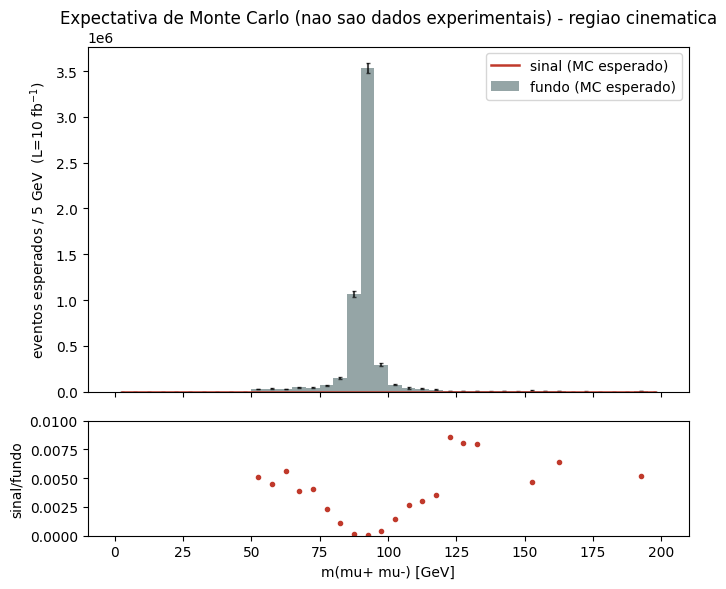

In [17]:
def yield_com_incerteza(mask, w_phys):
    n = int(mask.sum())
    return n * w_phys, np.sqrt(n) * w_phys

# Regiao "cinematica": cutflow ate Delta R > 0.4, sem MET
mask_s_cinematico = cf_sinal[3][1]
mask_b_cinematico = cf_fundo[3][1]
S_cin, errS_cin = yield_com_incerteza(mask_s_cinematico, w_phys_s)
B_cin, errB_cin = yield_com_incerteza(mask_b_cinematico, w_phys_b)

# Regiao final: com MET > 40 GeV
mask_s_final = cf_sinal[-1][1]
mask_b_final = cf_fundo[-1][1]
S_fin, errS_fin = yield_com_incerteza(mask_s_final, w_phys_s)
B_fin, errB_fin = yield_com_incerteza(mask_b_final, w_phys_b)

def linha_SB(nome, S, B, errS, errB):
    SB = S / B if B > 0 else np.inf
    S_sqrtB = S / np.sqrt(B) if B > 0 else np.inf
    B_syst = np.sqrt(B + (0.10 * B) ** 2) if B > 0 else 0.0
    S_sqrtB_syst = S / B_syst if B_syst > 0 else np.inf
    asimov_Z = np.sqrt(2 * ((S + B) * np.log(1 + S / B) - S)) if B > 0 else np.inf
    return dict(regiao=nome, S=S, erro_S=errS, B=B, erro_B=errB, S_sobre_B=SB,
                S_sobre_sqrtB=S_sqrtB, S_sobre_sqrtB_syst10pct=S_sqrtB_syst, asimov_Z=asimov_Z)

tabela_SB = pd.DataFrame([
    linha_SB("Selecao cinematica (sem MET)", S_cin, B_cin, errS_cin, errB_cin),
    linha_SB("Selecao final (com MET>40 GeV)", S_fin, B_fin, errS_fin, errB_fin),
])
pd.set_option("display.float_format", lambda x: f"{x:0.4g}")
print(tabela_SB.to_string(index=False))

# Histograma empilhado de m(mumu), pesos fisicos, na regiao cinematica (para B>0 ser visivel)
w_full_s = np.full(len(ev_tab_sinal), w_phys_s)
w_full_b = np.full(len(ev_tab_fundo), w_phys_b)

fig, (ax, axr) = plt.subplots(2, 1, figsize=(7, 6), sharex=True, gridspec_kw=dict(height_ratios=[3, 1]))
bins_m = np.linspace(0, 200, 41)
h_b, edges = np.histogram(ev_tab_fundo.m_mumu[mask_b_cinematico], bins=bins_m,
                           weights=w_full_b[mask_b_cinematico])
h_s, _ = np.histogram(ev_tab_sinal.m_mumu[mask_s_cinematico], bins=bins_m,
                       weights=w_full_s[mask_s_cinematico])
err_b = np.sqrt(np.histogram(ev_tab_fundo.m_mumu[mask_b_cinematico], bins=bins_m,
                              weights=w_full_b[mask_b_cinematico] ** 2)[0])
centers = 0.5 * (edges[:-1] + edges[1:])
width = edges[1] - edges[0]

ax.bar(centers, h_b, width=width, color="#95a5a6", label="fundo (MC esperado)", edgecolor="none")
ax.errorbar(centers, h_b, yerr=err_b, fmt="none", ecolor="black", capsize=1.5, alpha=0.7)
ax.step(centers, h_s, where="mid", color="#c0392b", lw=1.8, label="sinal (MC esperado)")
ax.set_ylabel(f"eventos esperados / {width:.0f} GeV  (L={L/1000:.0f} fb$^{{-1}}$)")
ax.set_title("Expectativa de Monte Carlo (nao sao dados experimentais) - regiao cinematica")
ax.legend()

razao = np.divide(h_s, h_b, out=np.full_like(h_s, np.nan), where=h_b > 0)
axr.axhline(1.0, color="gray", ls=":")
axr.plot(centers, razao, "o", ms=3, color="#c0392b")
axr.set_ylim(0, 0.01)
axr.set_xlabel("m(mu+ mu-) [GeV]"); axr.set_ylabel("sinal/fundo")
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/hist_normalizado_massa_mumu.png", dpi=130)
plt.show(); plt.close(fig)

**Leitura dos resultados:** sem o corte de MET, o fundo Drell–Yan domina completamente: $B\approx5{,}5\times10^{6}$ eventos esperados contra $S\approx3650$ eventos de sinal (para $L=10$ fb$^{-1}$), resultando em $S/B\approx6\times10^{-4}$ e $S/\sqrt B\approx1{,}5$ — uma razão desfavorável, mesmo com boa estatística individual (o fundo tem seção de choque quase 2000 vezes maior que a do sinal). O painel de razão sinal/fundo por bin de massa mostra que $S/B$ nunca ultrapassa 1% em nenhuma faixa de massa cinemática — a distinção não pode ser feita apenas pela massa do dimúon.

Após o corte de MET, $B\to0$: como discutido na Seção 4c, isso é um artefato do nível de gerador (MET verdadeiro é *exatamente* nulo para Drell–Yan sem neutrinos), e não deve ser interpretado como uma significância "infinita" alcançável experimentalmente. Em uma análise real, a cauda de resolução do MET manteria $B>0$, e $S/\sqrt B$ seria finito (embora provavelmente ainda muito favorável, dado o enorme poder de rejeição do MET para este par de processos).

## [6] Estimativa simplificada da seção de choque

Checagem de consistência: $\sigma_\text{estimado} = N/(A\varepsilon \cdot L)$, com $A\varepsilon = N_\text{pass}/N_\text{gerado}$ (aceitação vezes eficiência em nível de gerador) e $N=\sigma_\text{LHE}\cdot L\cdot A\varepsilon$ construído a partir da própria simulação. Usamos a região "cinemática" (antes do MET) para ter $N_\text{pass}>0$ em ambas as amostras.

In [18]:
def estimativa_sigma(nome, N_gerado, N_pass, sigma_lhe, L):
    Aeps = N_pass / N_gerado
    N = sigma_lhe * L * Aeps
    sigma_est = N / (Aeps * L) if Aeps > 0 else np.nan
    diff_rel = (sigma_est - sigma_lhe) / sigma_lhe if sigma_lhe != 0 else np.nan
    return dict(amostra=nome, N_gerado=N_gerado, N_pass=N_pass, A_vezes_eps=Aeps,
                N_esperado=N, sigma_LHE_pb=sigma_lhe, sigma_estimado_pb=sigma_est,
                diferenca_relativa=diff_rel)

est_sinal = estimativa_sigma("sinal", N_gerado_s, int(mask_s_cinematico.sum()), init_sinal["xsecup"], L)
est_fundo = estimativa_sigma("fundo", N_gerado_b, int(mask_b_cinematico.sum()), init_fundo["xsecup"], L)
tabela_sigma_est = pd.DataFrame([est_sinal, est_fundo])
pd.set_option("display.float_format", lambda x: f"{x:0.6g}")
tabela_sigma_est

,amostra,N_gerado,N_pass,A_vezes_eps,N_esperado,sigma_LHE_pb,sigma_estimado_pb,diferenca_relativa
0,sinal,10000,8300,0.83,3647.56,0.439465,0.439465,-1.26315e-16
1,fundo,10000,6587,0.6587,5.54388e+06,841.64,841.64,1.35078e-16


Como esperado, $\sigma_\text{estimado}$ reproduz exatamente $\sigma_\text{LHE}$ (diferença relativa $\sim10^{-16}$, compatível com precisão numérica), porque $N$ foi construído *a partir* da própria simulação — a fórmula $\sigma_\text{estimado}=N/(A\varepsilon\,L)$ é, por construção, apenas a inversão algébrica de $N=\sigma L(A\varepsilon)$. Trata-se puramente de um **teste de consistência da normalização** (nossa contabilidade de pesos e eficiências está correta), e não de uma medida independente da seção de choque.

Uma medida experimental real de $\sigma$ a partir de dados exigiria, adicionalmente:

- **subtração de fundo**, $N_\text{sinal}=N_\text{obs}-N_\text{fundo}$, com $N_\text{fundo}$ estimado a partir de controle em dados ou simulação validada — aqui não há "dados observados" independentes, apenas duas simulações;
- **eficiências reais** de trigger, reconstrução e identificação de múons (tipicamente $<100\%$ e dependentes de $p_T$/$\eta$), que reduziriam $A\varepsilon$ em relação ao valor de gerador calculado aqui;
- **correções de detector e unfolding**, para remover efeitos de resolução finita e migração entre bins antes de comparar com a seção de choque teórica;
- **incertezas estatísticas e sistemáticas** completas (luminosidade, calibração de energia, modelagem do MET, PDFs, etc.), que aqui foram tratadas apenas de forma simplificada (10% no fundo, Seção 5).

## [7] Discussão final

- **A proporção entre sinal e fundo faz sentido após a normalização?** Sim, e de forma reveladora: a seção de choque do fundo Drell–Yan ($\approx842$ pb) é quase 2000 vezes maior que a do sinal $WW\to2\mu2\nu$ ($\approx0{,}44$ pb), de modo que, sem um corte muito discriminante como o de MET, o fundo domina completamente qualquer seleção baseada apenas em cinemática de múons ($S/B\sim6\times10^{-4}$ na região cinemática). Isso é fisicamente esperado — a produção Drell–Yan é um processo eletrofraco de ordem mais baixa e com seção de choque tipicamente muito maior que a produção de pares de bósons de gauge massivos.
- **Estruturas nas massas invariantes:** a massa $m(\mu^+\mu^-)$ do fundo mostra um pico estreito na massa do $Z$ (91,19 GeV), associado à ressonância $Z\to\mu^+\mu^-$; o sinal não mostra nenhuma ressonância na massa do dimúon (os dois múons vêm de decaimentos de $W$ independentes), apenas um contínuo largo.
- **Etapa que mais melhora $S/B$:** o corte de MET, de longe — ele é o único capaz de suprimir totalmente o fundo Drell–Yan nesta amostra, ao custo de reter apenas ~49% do sinal remanescente antes desse corte.
- **A estimativa simples de seção de choque recupera o valor do LHE?** Sim, por construção (Seção 6) — é apenas um teste de consistência, não uma validação independente.
- **Por que essa inversão é apenas uma checagem de consistência em Monte Carlo?** Porque tanto $N$ (yield esperado) quanto $A\varepsilon$ (aceitação×eficiência) foram calculados a partir da mesma simulação e da mesma seção de choque $\sigma_\text{LHE}$; não há informação experimental independente entrando no cálculo, então o resultado é tautológico por construção algébrica.
- **As conclusões mudam quando as incertezas estatísticas são consideradas?** Na região cinemática, $S/\sqrt B\approx1{,}5$ (sem sistemáticas) já indica uma significância estatística modesta se dependêssemos apenas dessa seleção; incluir 10% de incerteza sistemática no fundo reduz ainda mais essa significância (fator de degradação visível na Seção 5). Já na "seleção final" com $B=0$, o conceito de $S/\sqrt B$ perde sentido (divisão por zero / significância formalmente infinita) — um sinal claro de que essa região é dominada por um artefato de simulação, não por uma medida estatisticamente robusta.
- **Efeitos ausentes de hadronização, detector, trigger e identificação de múons:** resolução finita de momento e de MET (fazendo o fundo "vazar" para MET$>0$), eficiências de trigger/reconstrução/isolamento tipicamente $<100\%$, pileup, radiação adicional via *parton shower* (ISR/FSR) alterando ligeiramente as distribuições cinemáticas, e possíveis contaminações de outros processos de fundo (ex.: $t\bar t$, diboson com jatos) não incluídas nesta amostra simplificada de apenas dois processos.
- **Próximo passo para se aproximar de uma análise CMS/ATLAS:** processar as amostras com um *parton shower*/hadronização (Pythia) e simulação rápida de detector (Delphes) para obter objetos reconstruídos realistas (múons calibrados, MET com resolução), incluir processos de fundo adicionais relevantes, aplicar uma seleção otimizada com base em um estudo de significância mais completo (por exemplo, otimização multivariada), e tratar sistematicamente as incertezas teóricas e experimentais antes de qualquer comparação com dados reais.